## Make comparison between CODEX lymph node and intestine 

## Install and import libraries

In [61]:
%pip install pandas seaborn matplotlib

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Load data

In [62]:
list_df = []

In [63]:
def download_csv(url:str, source:str):
  """Downloads the CSV at the provided URL and returns it as a pandas df

  Args:
      url (str): URL to CSV
  """
  
  df = pd.read_csv(url)
  df['source'] = source
  list_df.append(df)
  return df
  

In [64]:
df_intestine_small = download_csv('http://cdn.humanatlas.io/image-store/vccf-data-cell-nodes/published/intestine-codex-stanford/B006_Descending_Sigmoid-nodes.csv', 'intestine_small')
df_intestine_small

,x,y,Cell Type,source
0,4004.384,3366.142,NK,intestine_small
1,5186.474,6983.424,NK,intestine_small
2,3749.780,3487.382,NK,intestine_small
3,3584.374,3101.146,NK,intestine_small
4,3788.750,2837.016,NK,intestine_small
...,...,...,...,...
24580,5505.162,892.846,Stroma,intestine_small
24581,6650.014,1912.128,Stroma,intestine_small
24582,1276.484,188.788,Stroma,intestine_small
24583,2915.822,1302.464,Stroma,intestine_small


In [65]:
df_lymph_node = download_csv('http://cdn.humanatlas.io/image-store/vccf-data-cell-nodes/unpublished/lymphnode-codex-yale/LN00837-nodes.csv', 'lymph_node')
df_lymph_node

,x,y,Cell Type,source
0,16269.831479,8683.127186,FDC,lymph_node
1,18553.896989,7700.741680,FDC,lymph_node
2,14898.646825,9976.730159,FDC,lymph_node
3,19678.308571,11826.737143,FDC,lymph_node
4,14901.333333,9954.969136,FDC,lymph_node
...,...,...,...,...
369637,14848.231733,9167.459290,Mast,lymph_node
369638,14899.514925,9404.738806,Mast,lymph_node
369639,12579.616613,5712.654952,Mast,lymph_node
369640,14706.286765,9352.544118,Mast,lymph_node


In [66]:
df_intestine_large = download_csv('https://cdn.humanatlas.io/image-store/vccf-data-cell-nodes/unpublished/colon-xenium-stanford/layer_10-nodes.csv', 'intestine_large_layer_10')
df_intestine_large

,x,y,Cell Type,source
0,1111.426483,1860.016164,Immature Goblet,intestine_large_layer_10
1,1092.993737,1881.107858,Immature Goblet,intestine_large_layer_10
2,1096.557773,1877.851594,Immature Goblet,intestine_large_layer_10
3,1107.562526,1870.881701,Immature Goblet,intestine_large_layer_10
4,1097.215351,1884.347052,Immature Goblet,intestine_large_layer_10
...,...,...,...,...
90595,1358.506477,3618.395996,Unknown_lowcount,intestine_large_layer_10
90596,1356.518475,3628.975734,Unknown_lowcount,intestine_large_layer_10
90597,1348.169202,3627.602380,Unknown_lowcount,intestine_large_layer_10
90598,1347.356661,3614.886227,Immature Goblet,intestine_large_layer_10


In [67]:
df_merged = pd.concat(list_df, ignore_index=True)
df_merged

,x,y,Cell Type,source
0,4004.384000,3366.142000,NK,intestine_small
1,5186.474000,6983.424000,NK,intestine_small
2,3749.780000,3487.382000,NK,intestine_small
3,3584.374000,3101.146000,NK,intestine_small
4,3788.750000,2837.016000,NK,intestine_small
...,...,...,...,...
484822,1358.506477,3618.395996,Unknown_lowcount,intestine_large_layer_10
484823,1356.518475,3628.975734,Unknown_lowcount,intestine_large_layer_10
484824,1348.169202,3627.602380,Unknown_lowcount,intestine_large_layer_10
484825,1347.356661,3614.886227,Immature Goblet,intestine_large_layer_10


## Visualize

In [68]:
rc_params_dict = {
    'axes.labelsize': 18,        # fontsize for x and y labels
    'xtick.labelsize': 14,      # fontsize for x-axis tick labels
    'ytick.labelsize': 14,      # fontsize for y-axis tick labels
    'figure.titlesize': 20      # fontsize for figure titles
}

# Use sns.set_theme() to set the global rcParams
sns.set_theme(rc=rc_params_dict)

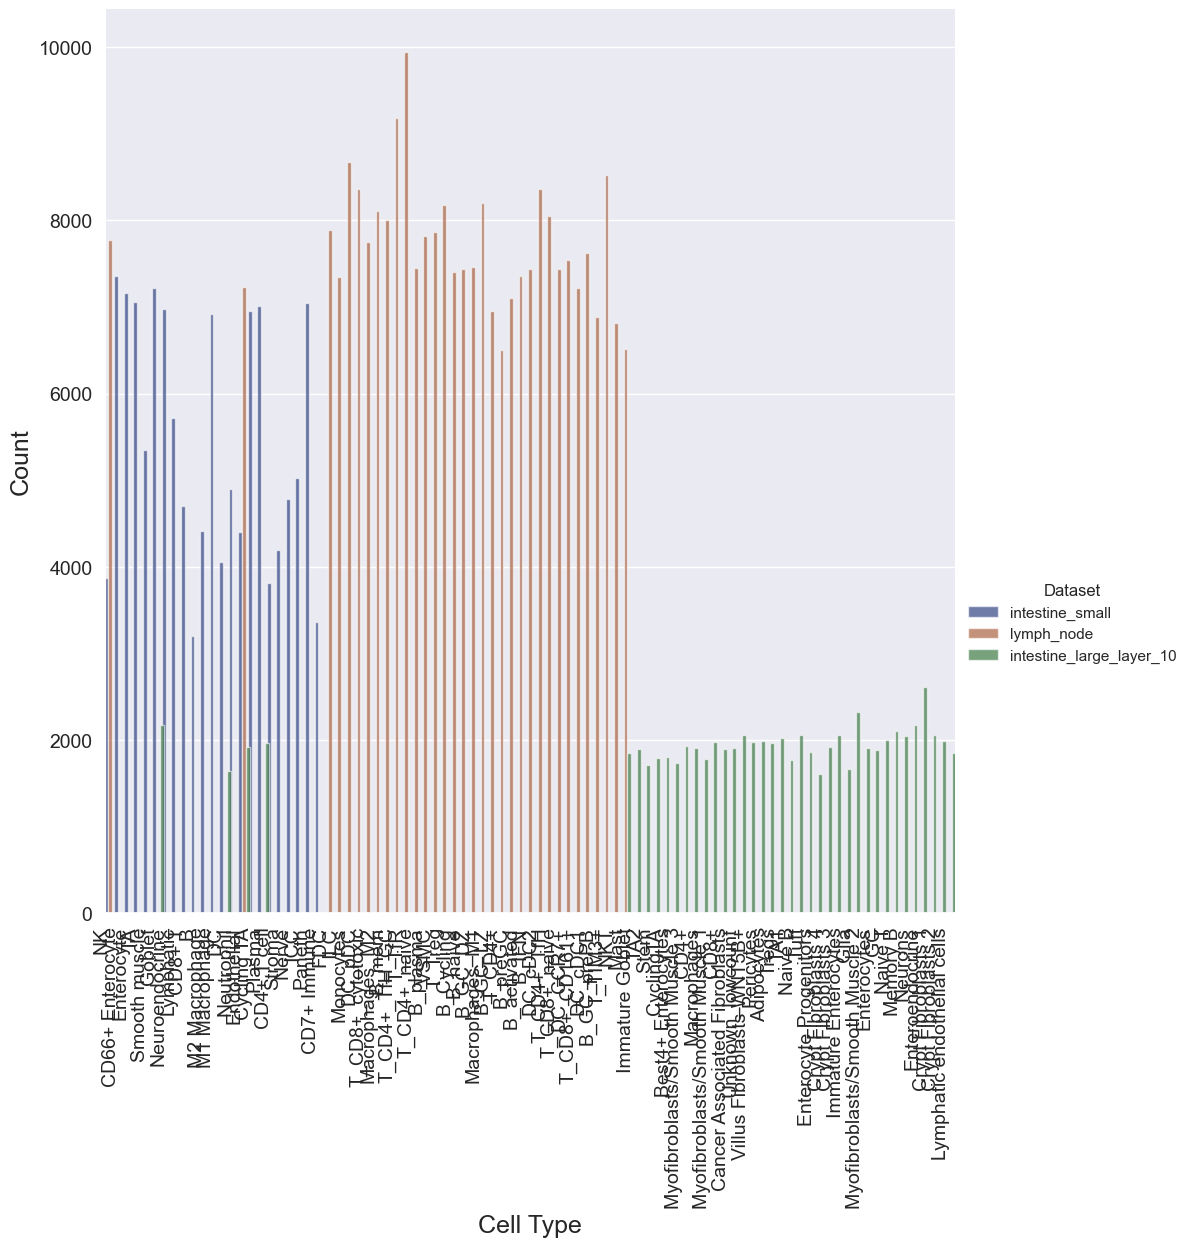

In [72]:
# Draw a nested barplot by species and sex
g = sns.catplot(
    data=df_merged, 
    kind="bar",
    x="Cell Type", 
    y="y", 
    hue="source",
    errorbar=None, 
    palette="dark", 
    alpha=.6, 
    width =1.2,
    height=10
)

# Rotate x-axis labels
plt.xticks(rotation=90, ha='right')

g.despine(left=True)
g.set_axis_labels("Cell Type", "Count")
g.legend.set_title("Dataset")